C:\Users\armin\AppData\Local\Temp\ipykernel_12320\2598210168.py:255: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\armin\AppData\Local\Temp\ipykernel_12320\2598210168.py:267: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


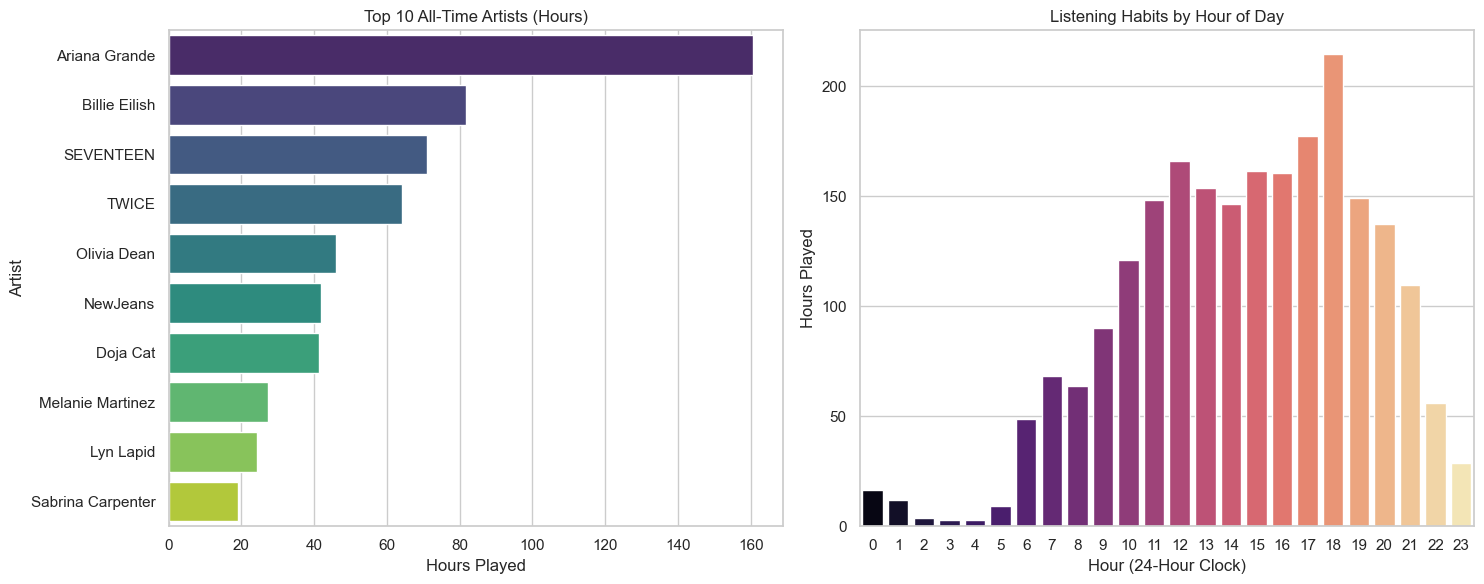

,hour,total_hours
0,0,16.356500
1,1,11.751833
2,2,3.596333
3,3,2.992667
4,4,3.036833
5,5,9.295833
6,6,48.854833
7,7,68.309667
8,8,63.795667
9,9,90.145000


,artist,hours_played
0,Ariana Grande,160.688833
1,Billie Eilish,81.681333
2,SEVENTEEN,71.116667
3,TWICE,64.120833
4,Olivia Dean,45.953667
5,NewJeans,41.870667
6,Doja Cat,41.354833
7,Melanie Martinez,27.207000
8,Lyn Lapid,24.442000
9,Sabrina Carpenter,19.106167


In [70]:
import sqlite3
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import textwrap
import scipy.stats as stats
import math

conn = sqlite3.connect("spotify_history.db")

# 1. TOP 10 ARTISTS (By total hours played)
top_artists = pd.read_sql_query(
    """
    SELECT master_metadata_album_artist_name AS artist, 
           SUM(minutes_played) / 60.0 AS hours_played
    FROM clean_streaming_history
    WHERE artist IS NOT NULL
    GROUP BY artist
    ORDER BY hours_played DESC
    LIMIT 10
""",
    conn,
)

# 2. LISTENING TIME BY HOUR OF DAY (0 - 23)
# Extracting the hour from timestamp string (assuming ISO format 'YYYY-MM-DDTHH:MM:SSZ')
listening_by_hour = pd.read_sql_query(
    """
    SELECT CAST(strftime('%H', ts) AS INTEGER) AS hour,
           SUM(minutes_played) / 60.0 AS total_hours
    FROM clean_streaming_history
    WHERE ts IS NOT NULL
    GROUP BY hour
    ORDER BY hour ASC
""",
    conn,
)

# 3. TOP ARTISTS PER YEAR
top_artists_per_year = pd.read_sql_query(
    """
    WITH YearlyArtist AS (
        SELECT
            strftime('%Y', ts) AS year_played,
            master_metadata_album_artist_name AS artist,
            ROUND(SUM(minutes_played)/60.0, 2) AS total_hours,
            ROW_NUMBER() OVER (
                PARTITION BY strftime('%Y', ts)
                ORDER BY SUM(minutes_played) DESC
            ) as rank
        FROM clean_streaming_history
        WHERE master_metadata_album_artist_name IS NOT NULL
        GROUP BY year_played, artist
        )
    SELECT year_played, artist, total_hours
    FROM YearlyArtist
    WHERE rank <= 5
    ORDER BY year_played DESC, rank ASC
    """,
    conn,
)
# top songs per year
top_songs_per_year = pd.read_sql_query(
    """
    WITH YearlySong AS (
        SELECT
            strftime('%Y', ts) AS year_played,
            master_metadata_album_artist_name AS artist,
            master_metadata_track_name AS song,
            ROUND(SUM(minutes_played)/60.0, 2) AS total_hours,
            ROW_NUMBER() OVER (
                PARTITION BY strftime('%Y', ts)
                ORDER BY SUM(minutes_played) DESC
            ) as rank
        FROM clean_streaming_history
        WHERE master_metadata_track_name IS NOT NULL
        GROUP BY year_played, song
        )
    SELECT year_played, artist, total_hours, song
    FROM YearlySong
    WHERE rank <= 5
    ORDER BY year_played DESC, rank ASC
    """,
    conn,
)

# number of hours listened per year
hours_per_year = pd.read_sql_query(
    """
    SELECT
        strftime('%Y', ts) as year_played,
        ROUND(SUM(minutes_played)/60.0,2) as total_time
    FROM clean_streaming_history
    GROUP BY year_played
    ORDER BY year_played DESC
    """,
    conn,
)

# total number of raw streams for mean median and mode
raw_streams = pd.read_sql_query(
    """
    SELECT 
        strftime('%Y', ts) AS year_played,
        minutes_played
    FROM clean_streaming_history
    WHERE minutes_played IS NOT NULL
    """,
    conn,
)
# total number of days listened per year
days_listened = pd.read_sql_query(
    """
    SELECT
        strftime('%Y', ts) AS year_played,
        ROUND(SUM(minutes_played) / 60.0, 2) AS total_hours,
        COUNT(DISTINCT DATE(ts)) AS days_active
    FROM clean_streaming_history
    GROUP BY year_played
    ORDER BY year_played ASC;
    """,
    conn,
)

# unique artists in total
unique_artists_in_total = pd.read_sql_query(
    """
    SELECT COUNT(DISTINCT master_metadata_album_artist_name) as artists
    FROM clean_streaming_history
    WHERE master_metadata_album_artist_name IS NOT NULL;
    """,
    conn,
)
# artist retention rates 
artist_retention = pd.read_sql_query(
    """
    WITH artist_years AS (
        SELECT 
            master_metadata_album_artist_name AS artist,
            COUNT(DISTINCT strftime('%Y', ts)) AS years_active
        FROM clean_streaming_history
        WHERE master_metadata_album_artist_name IS NOT NULL
        GROUP BY master_metadata_album_artist_name
    )
    SELECT 
        CASE 
            WHEN years_active > 1 THEN 'Repeat Artists (2+ Years)'
            ELSE 'One-Time Artists (1 Year Only)'
        END AS category,
        COUNT(*) AS artist_count
    FROM artist_years
    GROUP BY category;
    """,
    conn,
)
# total unique artists per year
unique_artists_per_year = pd.read_sql_query(
    """
    SELECT
        strftime('%Y', ts) as year,
        COUNT(DISTINCT master_metadata_album_artist_name) as artists
    FROM clean_streaming_history
    WHERE master_metadata_album_artist_name IS NOT NULL
    GROUP BY year
    ORDER BY year ASC;
    """,
    conn,
)
# total NEW artists discoveries per year
artist_discoveries_per_year = pd.read_sql_query(
    """
    WITH first_listen AS(
        SELECT
            master_metadata_album_artist_name AS artists,
            MIN(ts) AS first_listen_ts
        FROM clean_streaming_history
        WHERE master_metadata_album_artist_name IS NOT NULL
        GROUP BY master_metadata_album_artist_name
    )
    SELECT
        strftime('%Y', first_listen_ts) AS year,
        COUNT(artists) AS new_discovery
    FROM first_listen
    GROUP BY year
    """, 
    conn,
)
# cohort retention of artists
cohort_retention_df = pd.read_sql_query(
    """
    WITH first_listens AS (
        -- Step 1: Assign each artist to a Discovery Cohort Year
        SELECT 
            master_metadata_album_artist_name AS artist,
            CAST(strftime('%Y', MIN(ts)) AS INTEGER) AS cohort_year
        FROM clean_streaming_history
        WHERE master_metadata_album_artist_name IS NOT NULL
        GROUP BY master_metadata_album_artist_name
    ),
    artist_activity AS (
        -- Step 2: Check if the artist was played in any year AFTER their cohort year
        SELECT 
            fl.cohort_year,
            fl.artist,
            MAX(CASE WHEN CAST(strftime('%Y', csh.ts) AS INTEGER) > fl.cohort_year THEN 1 ELSE 0 END) AS listened_later
        FROM first_listens fl
        JOIN clean_streaming_history csh 
            ON fl.artist = csh.master_metadata_album_artist_name
        GROUP BY fl.cohort_year, fl.artist
    )
    -- Step 3: Aggregate retention rates by discovery year
    SELECT 
        cohort_year AS "Cohort Year",
        COUNT(artist) AS "Discovered Artists",
        SUM(listened_later) AS "Retained Artists",
        ROUND((CAST(SUM(listened_later) AS FLOAT) / COUNT(artist)) * 100, 1) AS "Retention Rate (%)"
    FROM artist_activity
    GROUP BY cohort_year
    ORDER BY cohort_year ASC;
    """,
    conn,
)

# listening concentration of top 5 artists compared to other artists per year
concentration_per_year = pd.read_sql_query(
    """
    WITH RankedArtists AS (
        SELECT
            strftime('%Y', ts) AS year_played,
            master_metadata_album_artist_name AS artist,
            SUM(minutes_played) / 60.0 AS hours_played,
            ROW_NUMBER() OVER (
                PARTITION BY strftime('%Y', ts)
                ORDER BY SUM(minutes_played) DESC
            ) AS rank
        FROM clean_streaming_history
        WHERE master_metadata_album_artist_name IS NOT NULL
        GROUP BY year_played, artist
    )
    SELECT 
        year_played,
        CASE 
            WHEN rank <= 5 THEN 'Top 5 Artists'
            ELSE 'Other Artists'
        END AS category,
        ROUND(SUM(hours_played), 2) AS total_hours
    FROM RankedArtists
    GROUP BY year_played, category
    ORDER BY year_played ASC, category DESC;
    """,
    conn,
)

conn.close()

# --- PLOT THE RESULTS ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Top Artists
sns.barplot(
    data=top_artists,
    y="artist",
    x="hours_played",
    ax=axes[0],
    palette="viridis",
)
axes[0].set_title("Top 10 All-Time Artists (Hours)")
axes[0].set_xlabel("Hours Played")
axes[0].set_ylabel("Artist")

# Plot 2: Peak Hours
sns.barplot(
    data=listening_by_hour,
    x="hour",
    y="total_hours",
    ax=axes[1],
    palette="magma",
)
axes[1].set_title("Listening Habits by Hour of Day")
axes[1].set_xlabel("Hour (24-Hour Clock)")
axes[1].set_ylabel("Hours Played")

plt.tight_layout()
plt.show()

df = listening_by_hour
df2 = top_artists
display(df)
display(df2.head(10))

## YEARLY LISTENING HABITS: CONTENT

C:\Users\armin\AppData\Local\Temp\ipykernel_12320\1384619783.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


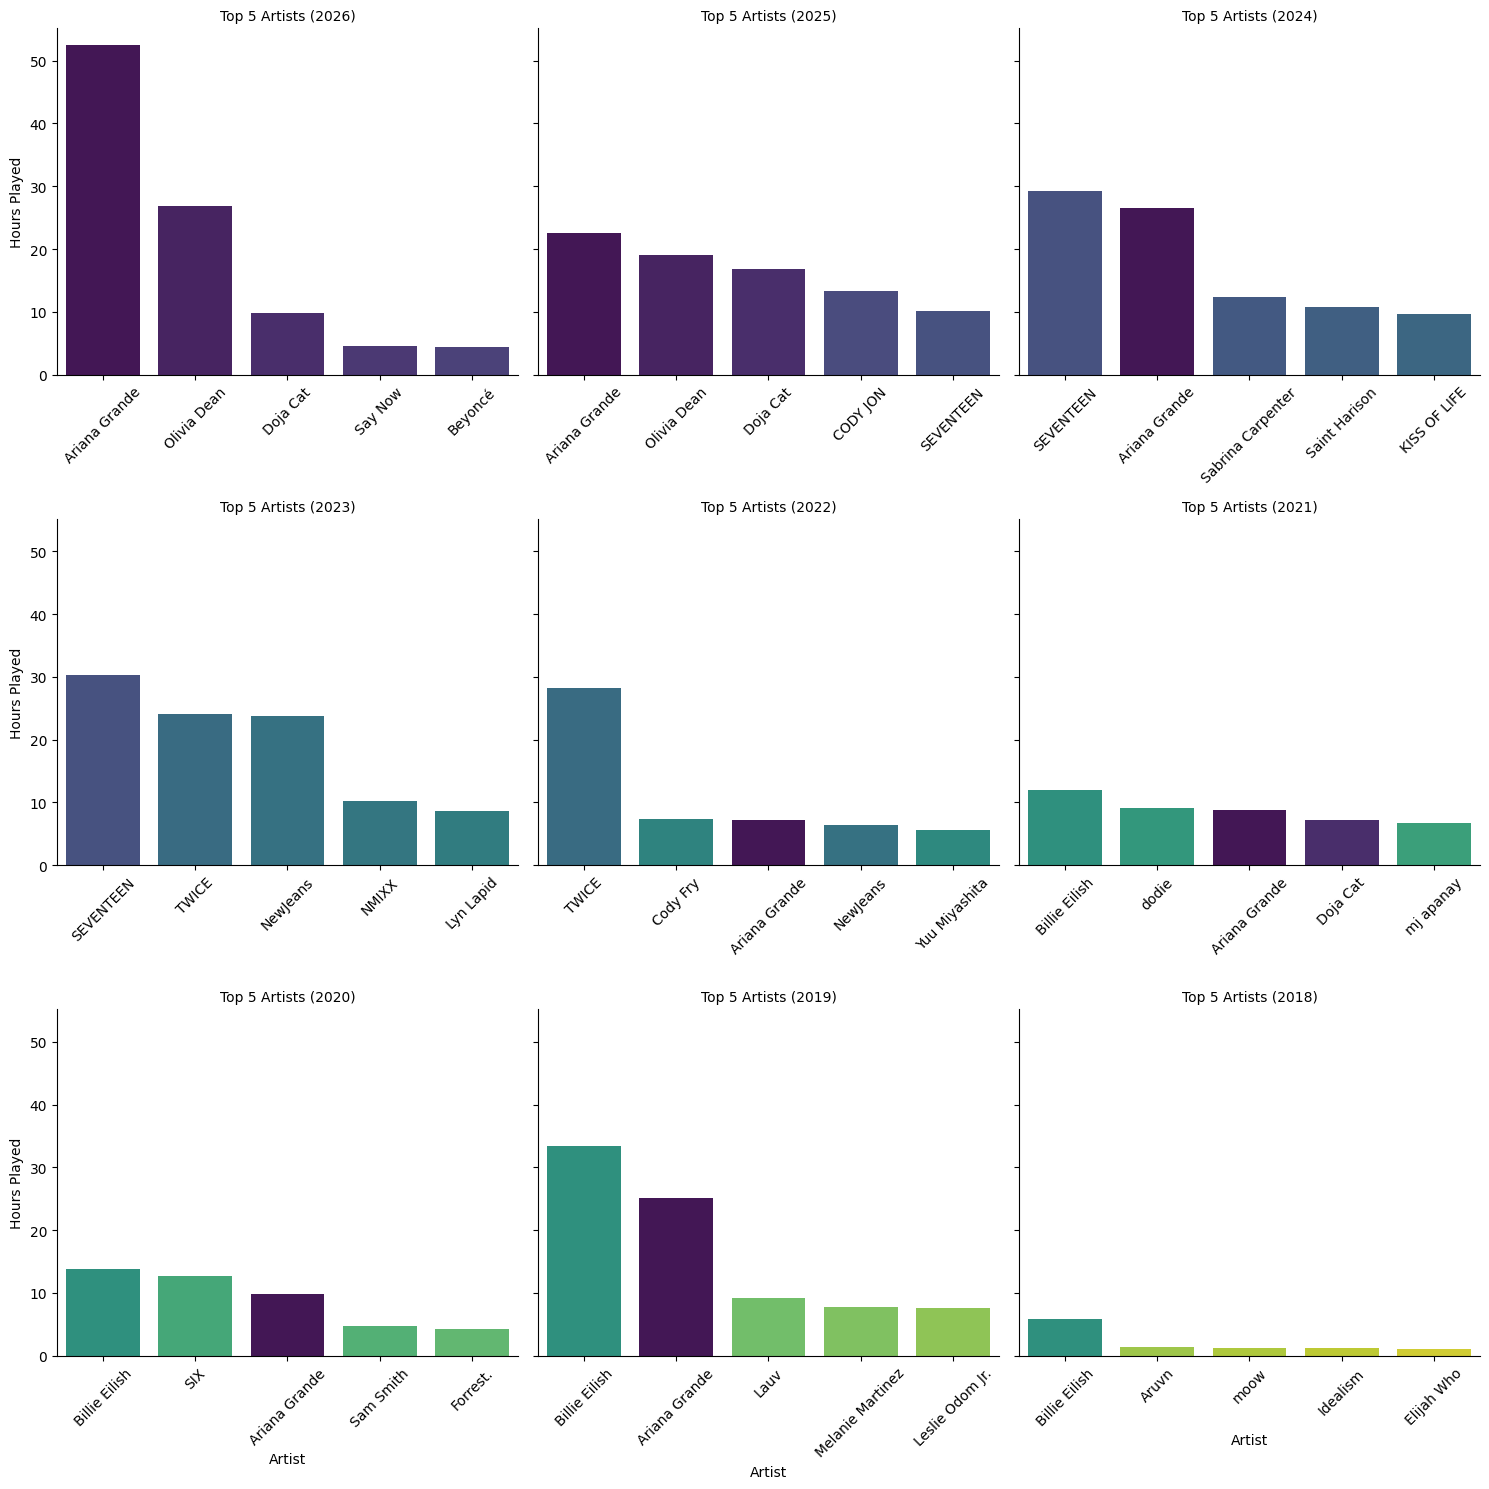

,year_played,artist,total_hours
0,2026,Ariana Grande,52.52
1,2026,Olivia Dean,26.88
2,2026,Doja Cat,9.80
3,2026,Say Now,4.58
4,2026,Beyoncé,4.34
5,2025,Ariana Grande,22.48
6,2025,Olivia Dean,19.07
7,2025,Doja Cat,16.89
8,2025,CODY JON,13.37
9,2025,SEVENTEEN,10.17


In [3]:
# Plot 3: Top 5 Artists per year
g = sns.catplot(
    data=top_artists_per_year,
    kind="bar",
    x="artist",
    y="total_hours",
    col="year_played",
    col_wrap=3,
    palette="viridis",
    sharex=False
)

g.set_titles("Top 5 Artists ({col_name})")
g.set_axis_labels("Artist", "Hours Played")
g.set_xticklabels(rotation=45)
plt.tight_layout()
plt.show()

df = top_artists_per_year
display(df)

C:\Users\armin\AppData\Local\Temp\ipykernel_12320\3126276918.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


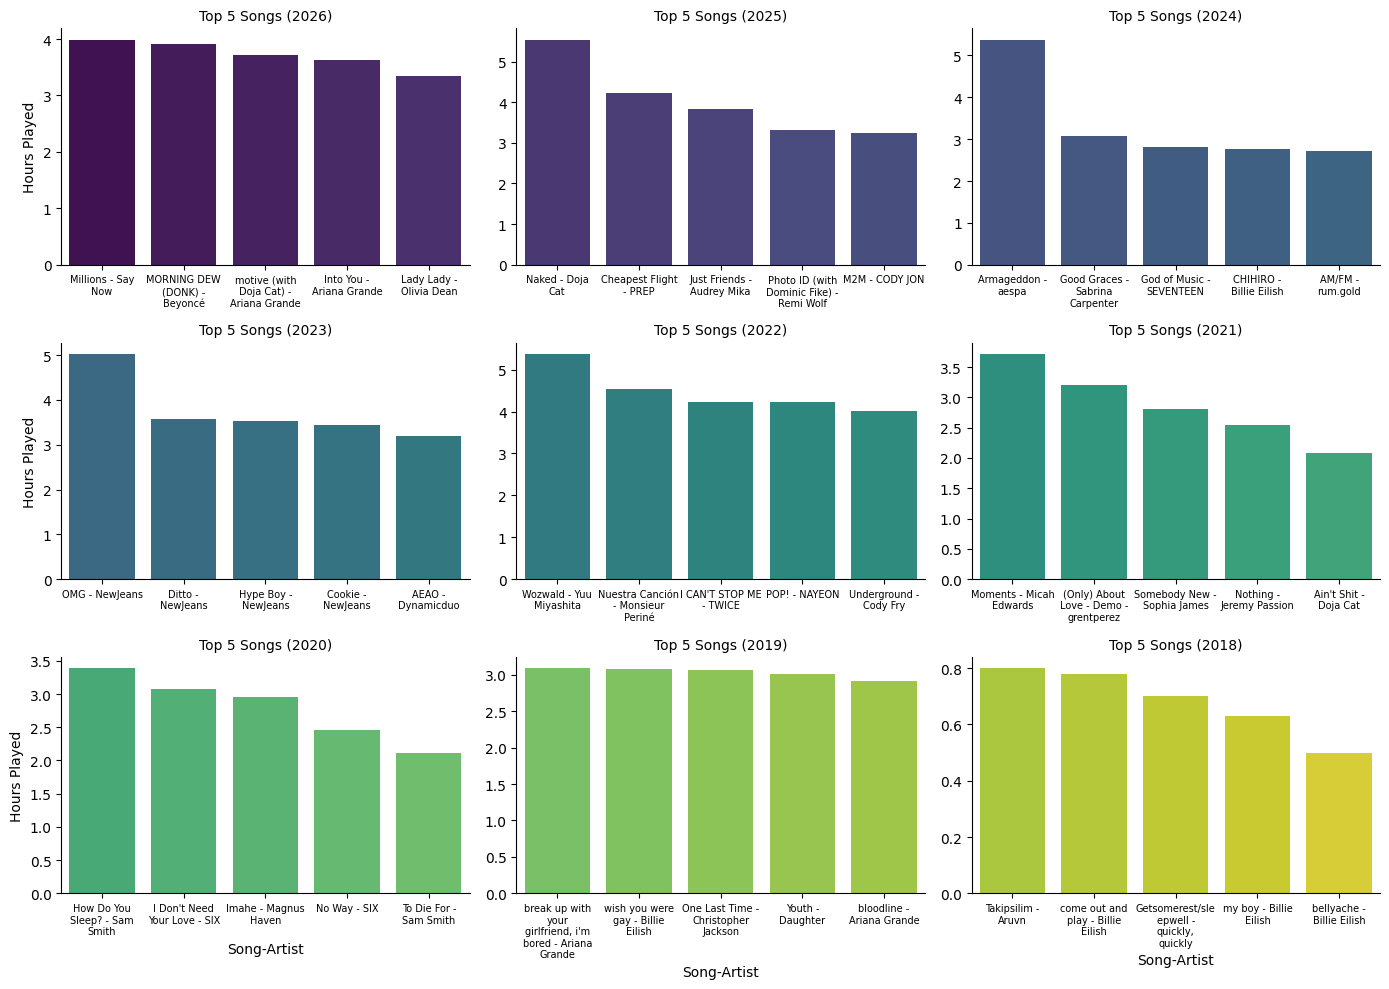

,year_played,artist,total_hours,song_artist
0,2026,Say Now,3.99,Millions - Say Now
1,2026,Beyoncé,3.91,MORNING DEW (DONK) - Beyoncé
2,2026,Ariana Grande,3.71,motive (with Doja Cat) - Ariana Grande
3,2026,Ariana Grande,3.63,Into You - Ariana Grande
4,2026,Olivia Dean,3.35,Lady Lady - Olivia Dean
5,2025,Doja Cat,5.54,Naked - Doja Cat
6,2025,PREP,4.22,Cheapest Flight - PREP
7,2025,Audrey Mika,3.83,Just Friends - Audrey Mika
8,2025,Remi Wolf,3.31,Photo ID (with Dominic Fike) - Remi Wolf
9,2025,CODY JON,3.24,M2M - CODY JON


In [4]:
# Plot 4: Top 5 SONGS per year
top_songs_per_year["song_artist"] = (top_songs_per_year["song"] + " - " + top_songs_per_year["artist"])
top_songs_per_year["wrapped_label"] = top_songs_per_year["song_artist"].apply(lambda x: "\n".join(textwrap.wrap(x, width=15)))
g = sns.catplot(
    data=top_songs_per_year,
    kind="bar",
    x="wrapped_label",
    y="total_hours",
    col="year_played",
    col_wrap=3,
    height=10,
    aspect=1.5,
    palette="viridis",
    sharey=False,
    sharex=False
)
g.figure.subplots_adjust(wspace=0.45)
g.set_titles("Top 5 Songs ({col_name})")
g.set_axis_labels("Song-Artist", "Hours Played")
g.fig.set_size_inches(14, 10)  # Make figure wider/taller
g.set_xticklabels(fontsize=7)  # Shrink label text slightly
plt.tight_layout()
plt.show()

df = top_songs_per_year.drop(columns=["song", "wrapped_label"])
display(df)

## YEARLY LISTENING HABITS: VOLUME AND ACTIVITY

C:\Users\armin\AppData\Local\Temp\ipykernel_12320\1347085800.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


,Year,Total Listening Time,Active Days
0,2026,247.5 hrs,243 days
1,2025,344.0 hrs,337 days
2,2024,315.3 hrs,327 days
3,2023,305.1 hrs,309 days
4,2022,289.0 hrs,301 days
5,2021,250.4 hrs,301 days
6,2020,219.2 hrs,314 days
7,2019,244.0 hrs,291 days
8,2018,34.8 hrs,14 days


,year_played,mean_minutes,median_minutes,mode_minutes
0,2018,2.38,2.28,1.60
1,2019,3.25,3.22,2.86
2,2020,3.02,3.09,3.23
3,2021,3.12,3.03,2.85
4,2022,3.06,3.08,3.42
5,2023,3.21,3.11,2.97
6,2024,3.17,3.07,2.76
7,2025,3.17,3.06,2.82
8,2026,3.12,3.07,3.47


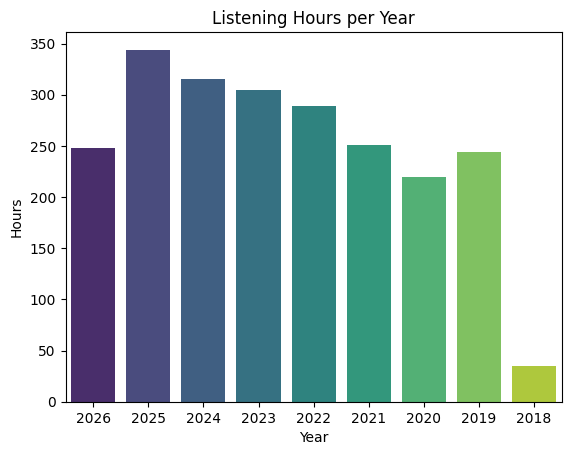

In [6]:
# Plot 5: Hours Listened per Year

fig = plt.plot(15,15)

sns.barplot(
    data=hours_per_year,
    y="total_time",
    x="year_played",
    palette="viridis",
)
plt.title("Listening Hours per Year")
plt.xlabel("Year")
plt.ylabel("Hours")

df1 = hours_per_year
df2 = days_listened
merged_df = pd.merge(df1, df2, on='year_played')
formatted_df = merged_df.copy().drop(columns='total_hours')
formatted_df["total_time"] = formatted_df["total_time"].apply(
    lambda x: f"{x:,.1f} hrs"
)
formatted_df["days_active"] = formatted_df["days_active"].apply(
    lambda x: f"{x} days"
)

# Rename columns for presentation
formatted_df.columns = ["Year", "Total Listening Time", "Active Days"]
display(formatted_df)

# Calculate summary stats per year
yearly_stats = (
    raw_streams.groupby("year_played")["minutes_played"]
    .agg(
        mean_minutes="mean",
        median_minutes="median",
        mode_minutes=lambda x: x.mode()[0] if not x.empty else None,
    )
    .reset_index()
)

# Convert values to rounded minutes or seconds for readability
yearly_stats["mean_minutes"] = yearly_stats["mean_minutes"].round(2)
display(yearly_stats)



,Year,Total Artists,New Discoveries,Repeat Artists,Discovery Rate (%),Repeat Rate (%)
0,2018,121,121,0,100.0,0.0
1,2019,340,279,61,82.1,17.9
2,2020,422,252,170,59.7,40.3
3,2021,415,262,153,63.1,36.9
4,2022,551,353,198,64.1,35.9
5,2023,407,189,218,46.4,53.6
6,2024,340,114,226,33.5,66.5
7,2025,740,303,437,40.9,59.1
8,2026,577,186,391,32.2,67.8


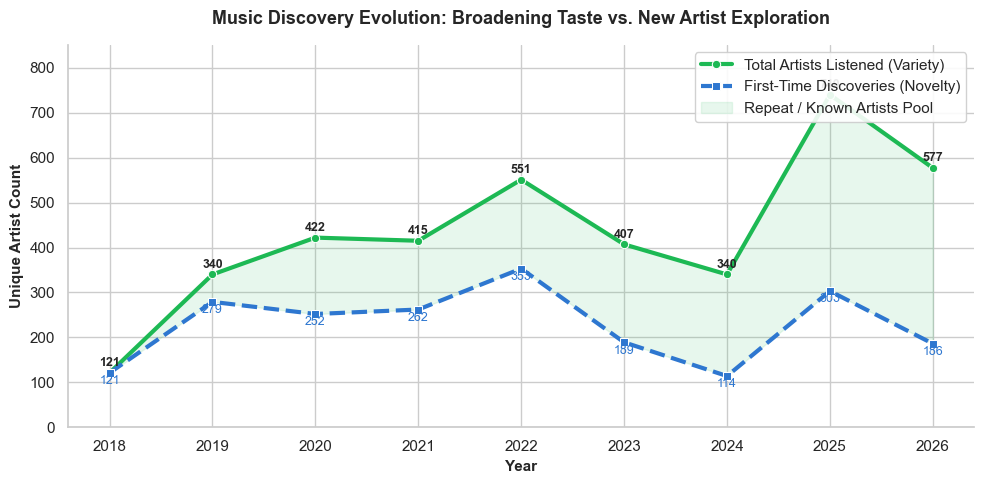

In [46]:
# plot unique artists overall, per year, and total new discoveries
discovery_summary = pd.merge(
    unique_artists_per_year,
    artist_discoveries_per_year,
    on="year",
    how="inner",
)

# 1. Calculate Repeat Artists Count
discovery_summary["repeat_artists"] = (
    discovery_summary["artists"] - discovery_summary["new_discovery"]
)

# 2. Calculate Discovery and Repeat Percentages
discovery_summary["discovery_pct"] = (
    (discovery_summary["new_discovery"] / discovery_summary["artists"]) * 100
).round(1)

discovery_summary["repeat_pct"] = (
    (discovery_summary["repeat_artists"] / discovery_summary["artists"]) * 100
).round(1)

# 3. Rename columns for clean display
formatted_summary = discovery_summary.rename(
    columns={
        "year": "Year",
        "artists": "Total Artists",
        "new_discovery": "New Discoveries",
        "repeat_artists": "Repeat Artists",
        "discovery_pct": "Discovery Rate (%)",
        "repeat_pct": "Repeat Rate (%)",
    }
)

display(formatted_summary)

# Set clean aesthetic styling
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Plot Total Artists (Variety)
ax = sns.lineplot(
    data=discovery_summary,
    x="year",
    y="artists",
    marker="o",
    linewidth=3,
    color="#1DB954",  # Spotify Green
    label="Total Artists Listened (Variety)",
)

# Plot New Discoveries (Novelty)
sns.lineplot(
    data=discovery_summary,
    x="year",
    y="new_discovery",
    marker="s",
    linewidth=3,
    linestyle="--",
    color="#2E77D0",  # Spotify Accent Blue
    label="First-Time Discoveries (Novelty)",
)

# Fill gap between lines to visually emphasize the "re-listen" gap
plt.fill_between(
    discovery_summary["year"],
    discovery_summary["new_discovery"],
    discovery_summary["artists"],
    color="#1DB954",
    alpha=0.1,
    label="Repeat / Known Artists Pool",
)

# Formatting for portfolio quality
plt.title(
    "Music Discovery Evolution: Broadening Taste vs. New Artist Exploration",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Year", fontsize=11, fontweight="bold")
plt.ylabel("Unique Artist Count", fontsize=11, fontweight="bold")
plt.ylim(0, discovery_summary["artists"].max() * 1.15)
plt.legend(frameon=True, facecolor="white", framealpha=0.9, loc="upper right")

# Annotate points directly on the chart
for idx, row in discovery_summary.iterrows():
    plt.text(
        row["year"],
        row["artists"] + 15,
        f"{int(row['artists'])}",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )
    plt.text(
        row["year"],
        row["new_discovery"] - 25,
        f"{int(row['new_discovery'])}",
        ha="center",
        fontsize=9,
        color="#2E77D0",
    )

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

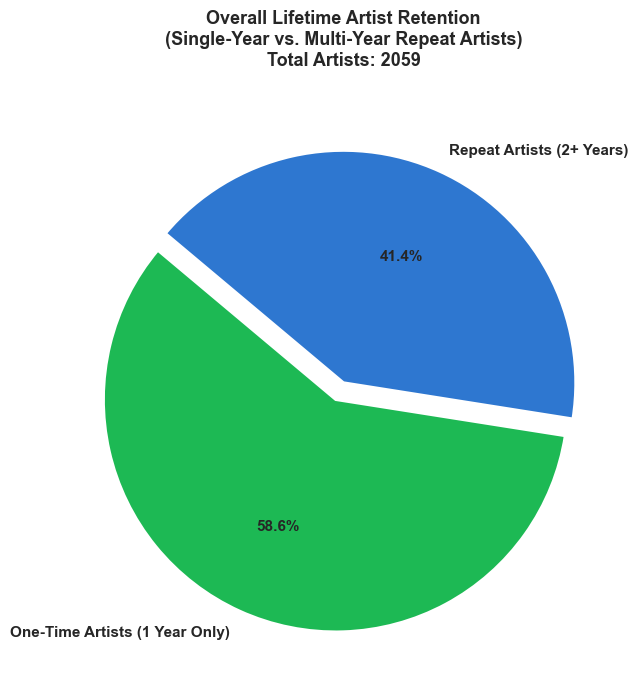

In [56]:
plt.figure(figsize=(7, 7))

colors = ["#1DB954", "#2E77D0"]  # Spotify Green & Blue

total_artists_count = unique_artists_in_total.iloc[0, 0]

plt.pie(
    artist_retention["artist_count"],
    labels=artist_retention["category"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    explode=(0.08, 0),  # Pulls the Repeat Artists slice out
    textprops={"fontsize": 11, "weight": "bold"},
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)

plt.title(
    f"Overall Lifetime Artist Retention\n(Single-Year vs. Multi-Year Repeat Artists)\nTotal Artists: {total_artists_count}",
    fontsize=13,
    fontweight="bold",
    pad=20,
)

plt.tight_layout()
plt.show()

,Cohort Year,Discovered Artists,Retained Artists,Retention Rate (%)
0,2018,121,87,71.9
1,2019,279,134,48.0
2,2020,252,146,57.9
3,2021,262,131,50.0
4,2022,353,118,33.4
5,2023,189,60,31.7
6,2024,114,66,57.9
7,2025,303,110,36.3
8,2026,186,0,0.0


C:\Users\armin\AppData\Local\Temp\ipykernel_12320\2322980478.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


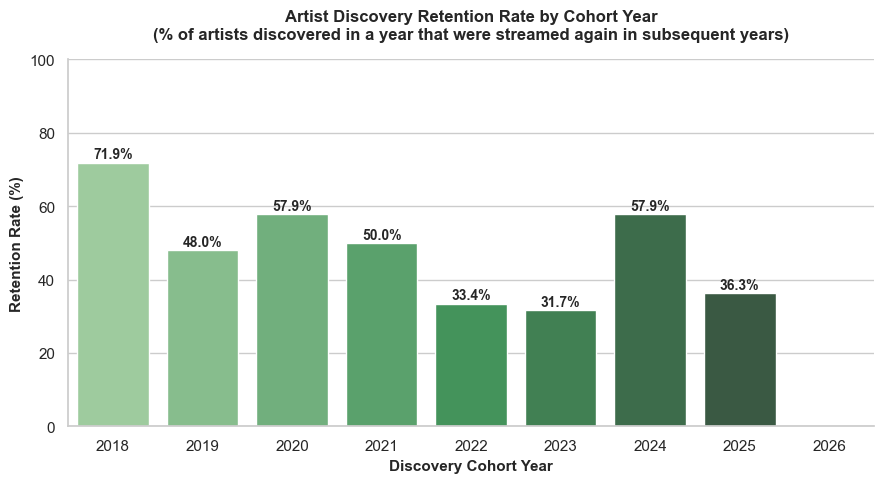

,year_played,category,total_hours
0,2018,Top 5 Artists,10.92
1,2018,Other Artists,23.91
2,2019,Top 5 Artists,82.89
3,2019,Other Artists,160.62
4,2020,Top 5 Artists,45.51
5,2020,Other Artists,172.96
6,2021,Top 5 Artists,43.77
7,2021,Other Artists,200.59
8,2022,Top 5 Artists,54.82
9,2022,Other Artists,233.51


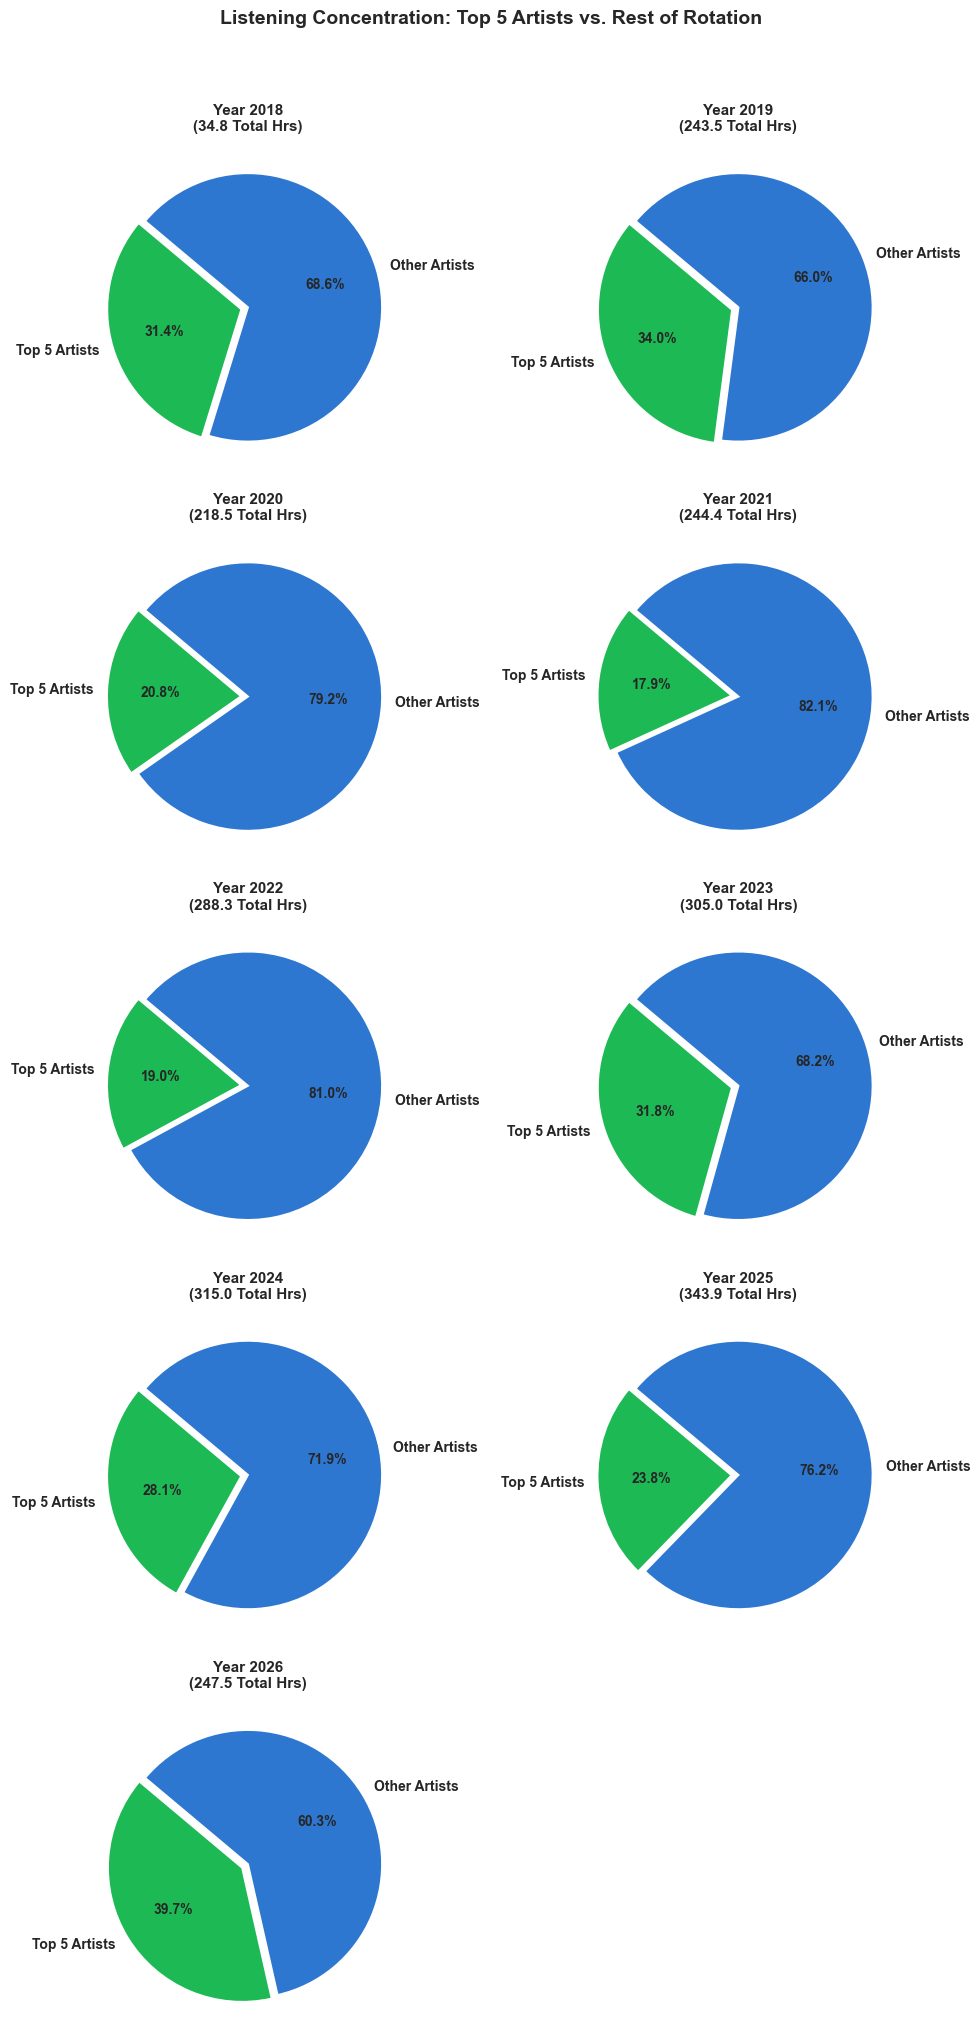

In [74]:
display(cohort_retention_df)

plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# Bar plot for Cohort Retention Rate
ax = sns.barplot(
    data=cohort_retention_df,
    x="Cohort Year",
    y="Retention Rate (%)",
    palette="Greens_d",
)

# Format chart title and labels
plt.title(
    "Artist Discovery Retention Rate by Cohort Year\n(% of artists discovered in a year that were streamed again in subsequent years)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Discovery Cohort Year", fontsize=11, fontweight="bold")
plt.ylabel("Retention Rate (%)", fontsize=11, fontweight="bold")
plt.ylim(0, 100)

# Add numeric labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="center",
            xytext=(0, 6),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
        )

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

# concentration
display(concentration_per_year)
# Identify unique years sorted chronologically
years = sorted(concentration_per_year["year_played"].unique())
num_years = len(years)

# Create a dynamic subplot grid (2 charts per row)
cols = 2
rows = math.ceil(num_years / cols)
fig, axes = plt.subplots(rows, cols, figsize=(10, 4 * rows))
axes = axes.flatten() if num_years > 1 else [axes]

# Spotify color palette: Spotify Green for Top 5, Muted Dark Blue for Rest
colors = ["#1DB954", "#2E77D0"]

for idx, year in enumerate(years):
    ax = axes[idx]
    year_data = concentration_per_year[
        concentration_per_year["year_played"] == year
    ]

    ax.pie(
        year_data["total_hours"],
        labels=year_data["category"],
        autopct="%1.1f%%",
        startangle=140,
        colors=colors,
        explode=(0.05, 0),
        textprops={"fontsize": 10, "weight": "bold"},
        wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    )

    total_yearly_hrs = year_data["total_hours"].sum()
    ax.set_title(
        f"Year {year}\n({total_yearly_hrs:,.1f} Total Hrs)",
        fontsize=11,
        fontweight="bold",
    )

# Hide unused subplot axes if total years is an odd number
for idx in range(num_years, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle(
    "Listening Concentration: Top 5 Artists vs. Rest of Rotation",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()